# 1. Single image analysis

In [ ]:
import timeit
import numpy as np

# Simular datos
px_per_cm = 37.5
area_px = 1500.0
perimeter_px = 150.0

# Código 1: Tu implementación (optimizada)
def optimized_version():
    inv_px_per_cm = 1.0 / px_per_cm
    inv_px_per_cm_sq = inv_px_per_cm * inv_px_per_cm
    area_val = area_px * inv_px_per_cm_sq
    perimeter_val = perimeter_px * inv_px_per_cm
    return area_val, perimeter_val

# Código 2: Versión directa
def direct_version():
    area_cm = area_px / (px_per_cm ** 2)
    per_cm = perimeter_px / px_per_cm
    return area_cm, per_cm

# Medir tiempos
n_iterations = 1_000_000

time_optimized = timeit.timeit(optimized_version, number=n_iterations)
time_direct = timeit.timeit(direct_version, number=n_iterations)

print(f"{'Método':<20} {'Tiempo (s)':<15} {'Tiempo por operación (ns)':<30}")
print("=" * 65)
print(f"{'Optimizado':<20} {time_optimized:<15.6f} {(time_optimized/n_iterations)*1e9:<30.2f}")
print(f"{'Directo':<20} {time_direct:<15.6f} {(time_direct/n_iterations)*1e9:<30.2f}")
print("=" * 65)
print(f"Diferencia: {((time_direct - time_optimized) / time_direct * 100):.2f}% más rápido (optimizado)")
print(f"Speedup: {time_direct / time_optimized:.2f}x")

# Verificar que dan el mismo resultado
result_opt = optimized_version()
result_dir = direct_version()
print(f"\n✓ Resultados idénticos: {np.allclose(result_opt, result_dir)}")
print(f"  Optimizado: área={result_opt[0]:.6f}, perímetro={result_opt[1]:.6f}")
print(f"  Directo:    área={result_dir[0]:.6f}, perímetro={result_dir[1]:.6f}")

In [ ]:
import timeit
import numpy as np

# Simular procesamiento de muchos frutos
n_fruits = 10_000
px_per_cm = 37.5
areas_px = np.random.uniform(500, 3000, n_fruits)
perimeters_px = np.random.uniform(80, 200, n_fruits)

def process_optimized():
    inv_px_per_cm = 1.0 / px_per_cm
    inv_px_per_cm_sq = inv_px_per_cm * inv_px_per_cm
    areas_cm = areas_px * inv_px_per_cm_sq
    perimeters_cm = perimeters_px * inv_px_per_cm
    return areas_cm, perimeters_cm

def process_direct():
    areas_cm = areas_px / (px_per_cm ** 2)
    perimeters_cm = perimeters_px / px_per_cm
    return areas_cm, perimeters_cm

n_runs = 1000
time_opt = timeit.timeit(process_optimized, number=n_runs)
time_dir = timeit.timeit(process_direct, number=n_runs)

print(f"\nProcesando {n_fruits} frutos, {n_runs} veces:")
print(f"Optimizado: {time_opt:.4f}s")
print(f"Directo:    {time_dir:.4f}s")
print(f"Diferencia: {((time_dir - time_opt) / time_dir * 100):.2f}% más rápido")

In [1]:
from traitly.internal_structure import FruitAnalyzer


In [2]:
path = '/Users/alejandra/Downloads/IMG_20250726_0004.jpg'
cranberry = FruitAnalyzer(path)

cranberry.read_image(plot = False)

In [3]:
cranberry.setup_measurements(diameter_cm = 1.7)


1. LABEL DETECTION:
> No QR detected.
> Label text detection: SKIPPED (label=False)

2. REFERENCE SIZE:
Image dimensions:
    - Width:  2,550 pixels
    - Length: 3,300 pixels

No size reference detected.
Missing parameters: width_cm, length_cm

 IMPORTANT: Measurements will be returned in >> PIXEL << units


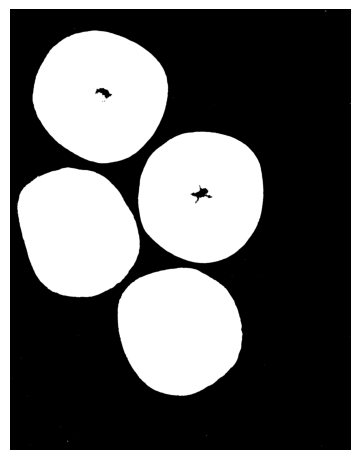

In [4]:
cranberry.create_mask(plot = True, kernel_blur = 1)

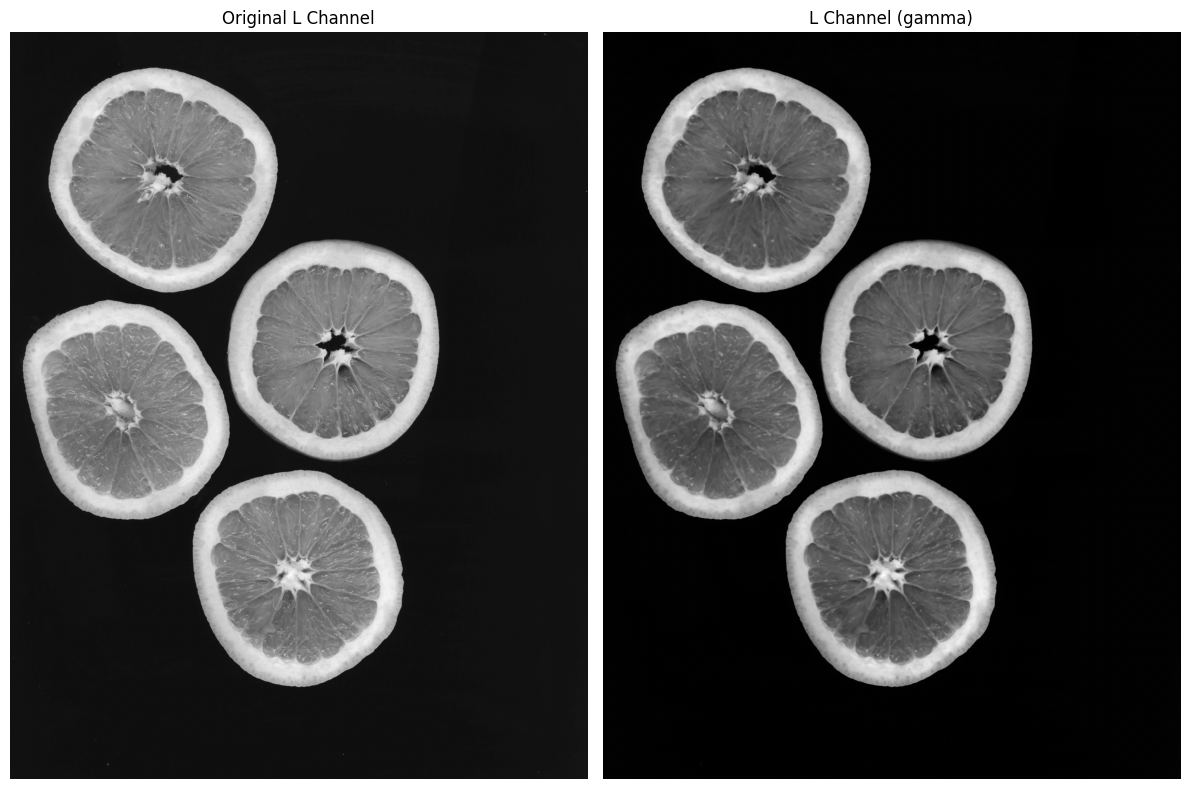

In [5]:
cranberry.apply_contrast(contrast_method = 'gamma', plot = True, kernel_blur = 7)

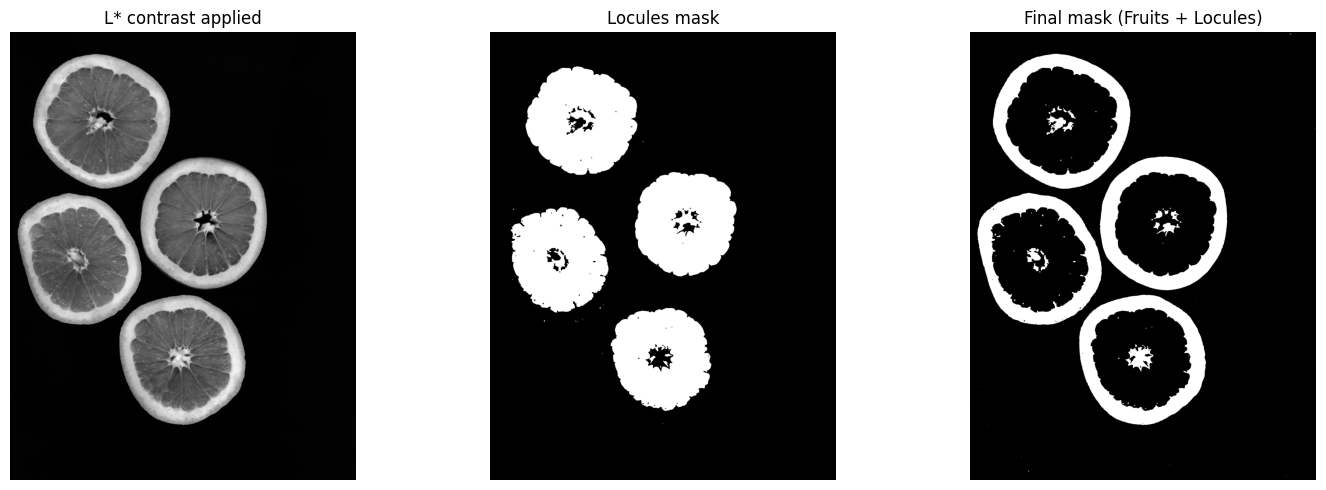

In [15]:
cranberry.create_mask_locules(plot = True, kernel_close = 6)

In [22]:
cranberry.find_fruits(min_circularity = 0.1, min_locule_area = 50)

Total detected objects: 155
Detected fruits after filtering: 4


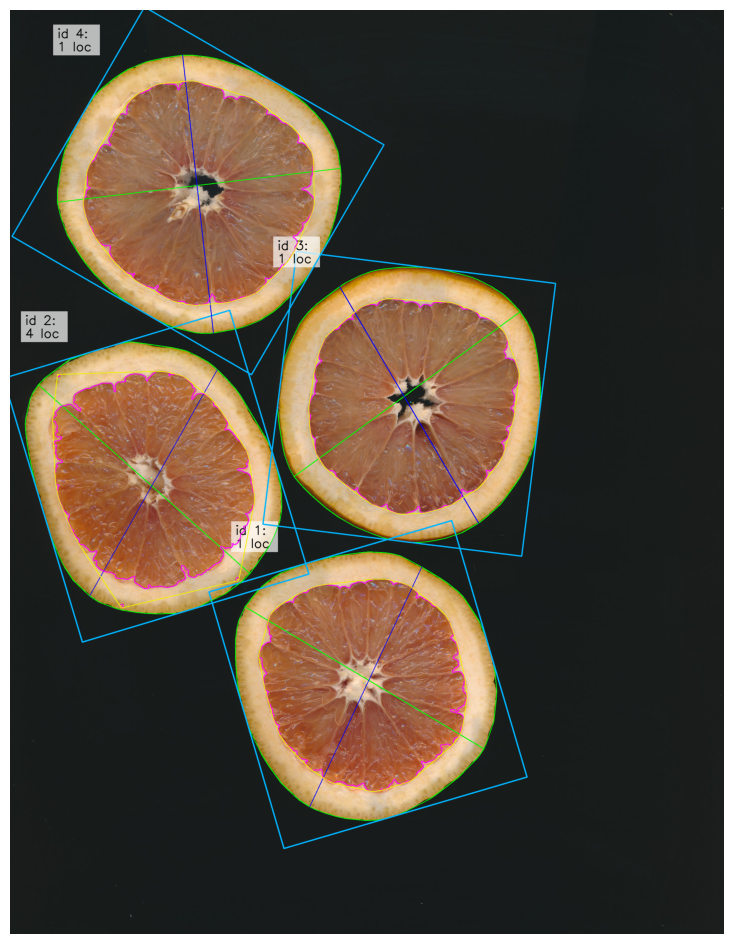

In [24]:
cranberry.analyze_image(plot_size = (12,12), plot = True, contour_mode = 'hull', min_locule_area = 50)

In [76]:
import pandas as pd

pd.DataFrame(cranberry.results.results)

,image_name,label,fruit_id,n_locules,unit,fruit_area_cm2,fruit_perimeter_cm,fruit_circularity,fruit_solidity,fruit_compactness,...,internal_flesh_area_cm2,internal_cavity_area_cm2,locule_cavity_area_cm2,outer_pericarp_ratio,internal_cavity_ratio,locule_to_fruit_ratio,locule_to_cavity_ratio,flesh_to_cavity_ratio,locule_to_fruit_percentage,locule_to_cavity_percentage
0,img_test_1.jpg,DP14-106,1,4,cm,3.685375,7.182323,0.897763,0.993037,13.997426,...,0.598382,1.524296,0.925914,0.586393,0.413607,0.251240,0.607437,0.392563,25.124005,60.743713
1,img_test_1.jpg,DP14-106,2,4,cm,3.253422,6.804697,0.882943,0.992498,14.232371,...,0.447208,1.345110,0.897902,0.586555,0.413445,0.275987,0.667530,0.332470,27.598682,66.753031
2,img_test_1.jpg,DP14-106,3,4,cm,3.098369,6.650387,0.880337,0.990061,14.274496,...,0.339434,1.381605,1.042171,0.554086,0.445914,0.336361,0.754319,0.245681,33.636113,75.431917
3,img_test_1.jpg,DP14-106,4,4,cm,3.733574,7.253913,0.891641,0.993022,14.093533,...,0.525590,1.801458,1.275869,0.517498,0.482502,0.341728,0.708242,0.291758,34.172846,70.824208
4,img_test_1.jpg,DP14-106,5,4,cm,3.548799,7.091732,0.886720,0.991731,14.171743,...,0.488174,1.344452,0.856278,0.621153,0.378847,0.241287,0.636897,0.363103,24.128666,63.689719
5,img_test_1.jpg,DP14-106,6,4,cm,3.669725,7.237695,0.880325,0.991807,14.274701,...,0.573131,1.501412,0.928281,0.590865,0.409135,0.252957,0.618272,0.381728,25.295657,61.827180
6,img_test_1.jpg,DP14-106,7,4,cm,3.168465,6.677258,0.893023,0.992400,14.071729,...,0.407360,1.192884,0.785524,0.623514,0.376486,0.247919,0.658508,0.341492,24.791948,65.850835
7,img_test_1.jpg,DP14-106,8,4,cm,4.942963,8.331219,0.894912,0.993905,14.042026,...,0.530653,2.345328,1.814675,0.525522,0.474478,0.367123,0.773740,0.226260,36.712296,77.374043
8,img_test_1.jpg,DP14-106,9,4,cm,5.569357,8.883308,0.886881,0.992535,14.169169,...,0.660324,2.258924,1.598600,0.594401,0.405599,0.287035,0.707682,0.292318,28.703496,70.768201
9,img_test_1.jpg,DP14-106,10,4,cm,4.038354,7.541425,0.892293,0.991924,14.083235,...,0.539990,1.865899,1.325909,0.537956,0.462044,0.328329,0.710601,0.289399,32.832905,71.060051


In [77]:
cranberry.results.save_all()

# cranberry.results.save_img() # Save only the annotated_image
# cranberry.results.save_csv() # Save only the csv results table

Image saved at: /Users/alejandra/Documents/traitly/tests/sample_data/img_test_1_annotated.jpg
CSV saved at: /Users/alejandra/Documents/traitly/tests/sample_data/img_test_1_results.csv
Error report saved at: /Users/alejandra/Documents/traitly/tests/sample_data/error_report.csv
Session report saved at: /Users/alejandra/Documents/traitly/tests/sample_data/session_report.txt


# 2. Batch analysis

In [33]:
path = '/Users/alejandra/Documents/traitly/tests/sample_data'
cranberry_batch = FruitAnalyzer(path)

cranberry_batch.analyze_folder()

Traitly running ⋆✧｡٩(ˊᗜˋ )و✧*｡   
Sequential mode: processing 6 image(s) one at a time


Processing images: 100%|██████████| 6/6 [00:11<00:00,  1.94s/image]


 ( ദ്ദി ˙ᗜ˙ )   Processing completed !
══════════════════════════════════════════════════════════════════════
- Total time: 0.19 minutes (~1.94 sec/image)
-  Total images processed: 6
- Successfully annotated: 5
- Failed (errors): 1
- RAM used: 0.01 GB (peak: 1.43 GB)
> Output folder: /Users/alejandra/Documents/traitly/tests/sample_data/Results
> Error report saved in: /Users/alejandra/Documents/traitly/tests/sample_data/Results/error_report.csv


# 3. Stamp analysis


LABEL DETECTION:
> No QR detected.
> Label text detection: SKIPPED (label=False)

REFERENCE SIZE:
Image dimensions:
    - Width:  2,478 pixels
    - Length: 3,231 pixels

No size reference detected.
Missing parameters: width_cm, length_cm

 IMPORTANT: Measurements will be returned in >> PIXEL << units
Total detected objects: 175
Detected fruits after filtering: 21


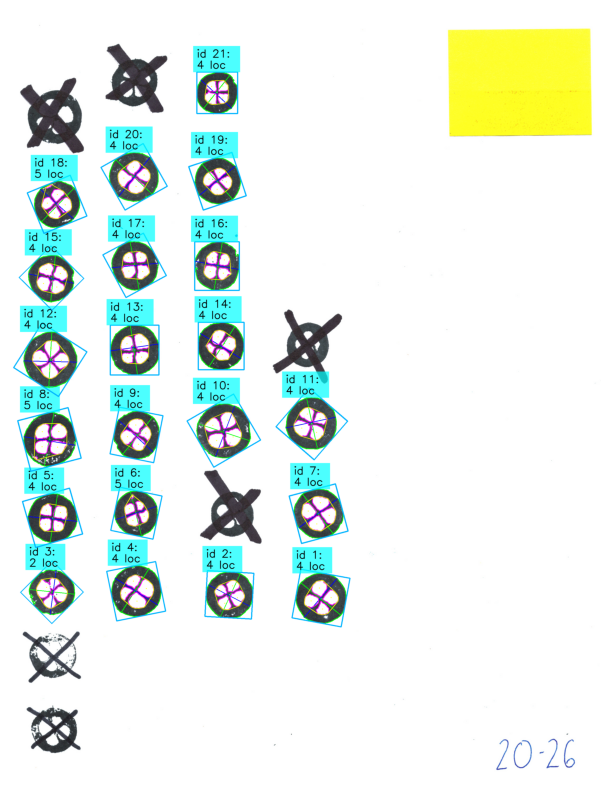

In [ ]:
path_stamp = '/Users/alejandra/Documents/traitly/tests/sample_data/stamp/img_test_6.jpg'

cranberry_stamp = FruitAnalyzer(path_stamp)
cranberry_stamp.read_image()
cranberry_stamp.setup_measurements()
cranberry_stamp.create_mask(stamp = True) # <- declare that the input are stamps 
cranberry_stamp.find_fruits()
cranberry_stamp.analyze_image(label_color = (255,255,0)) # Change label color from white to cyan

# 4. Fruits with complex locules analysis

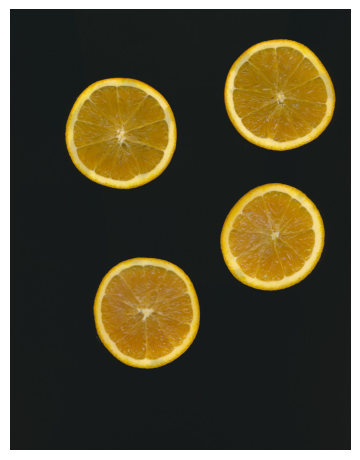


LABEL DETECTION:
> No QR detected.
> Label text detection: SKIPPED (label=False)

REFERENCE SIZE:
Image dimensions:
    - Width:  3,400 pixels
    - Length: 4,400 pixels

No size reference detected.
Reference circles not detected. Using provided physical dimensions:
    - Width:  21.5 cm
    - Length: 27.9 cm

>>> Calculated px/cm density: 157.92 px/cm


In [43]:
path_orange = '/Users/alejandra/Documents/traitly/tests/sample_data/orange.jpg'

orange = FruitAnalyzer(path_orange)
orange.read_image(plot = True)
orange.setup_measurements(width_cm = 21.5, length_cm = 27.9)


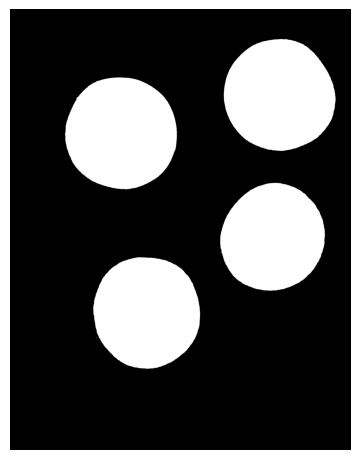

In [ ]:
orange.create_mask(plot = True) # Fruit mask created

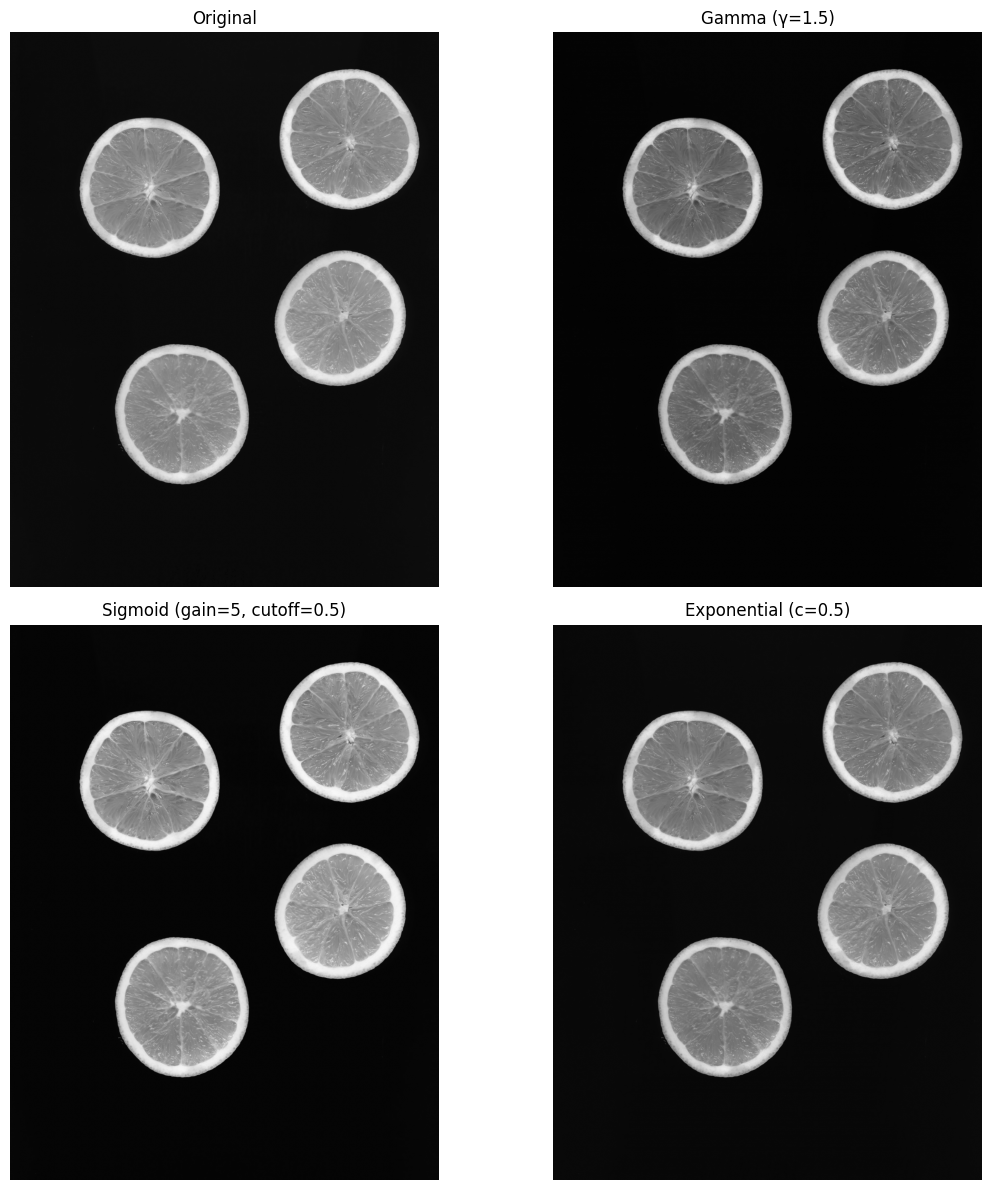

In [ ]:
# Apply bw contrast to segment only the locules 

# First, compare contrast methods available and choose the best one for your fruits:
orange.apply_contrast(plot = True, compare = True) 

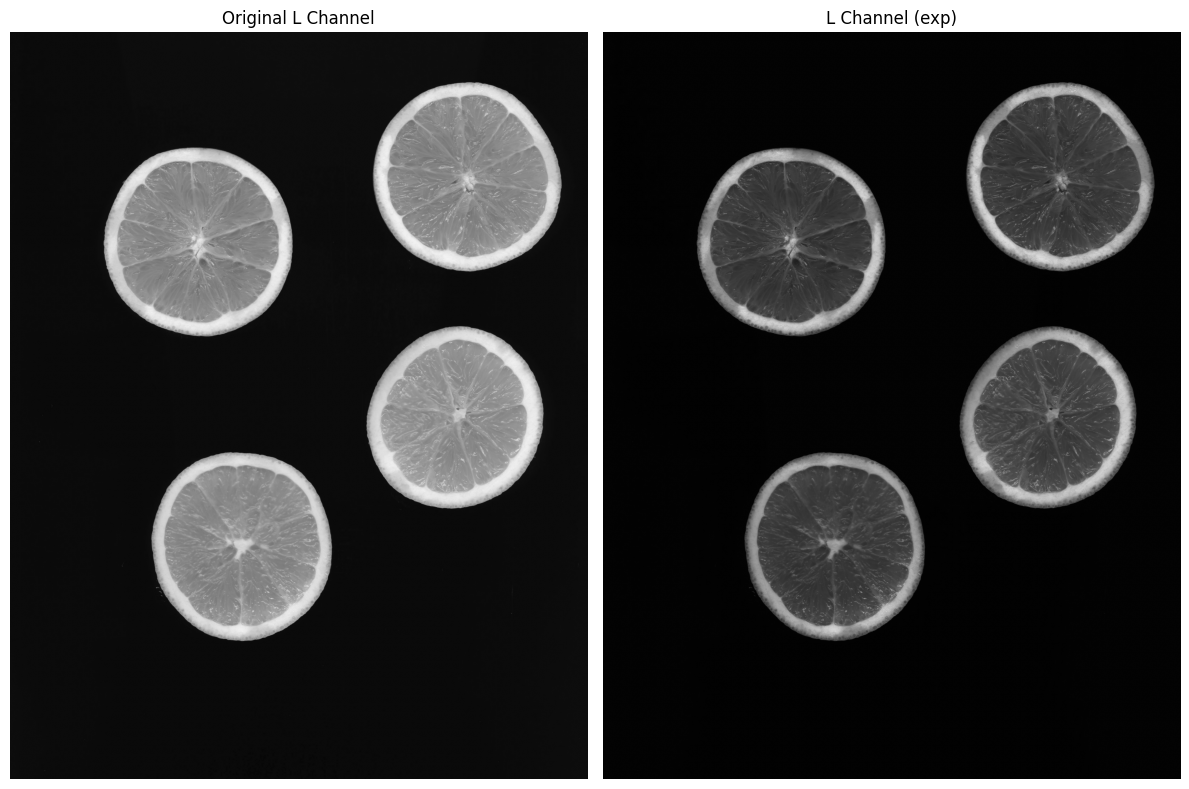

In [ ]:
# Then, apply that specific method on your image
orange.apply_contrast(contrast_method = 'exp', c = 3, plot = True)

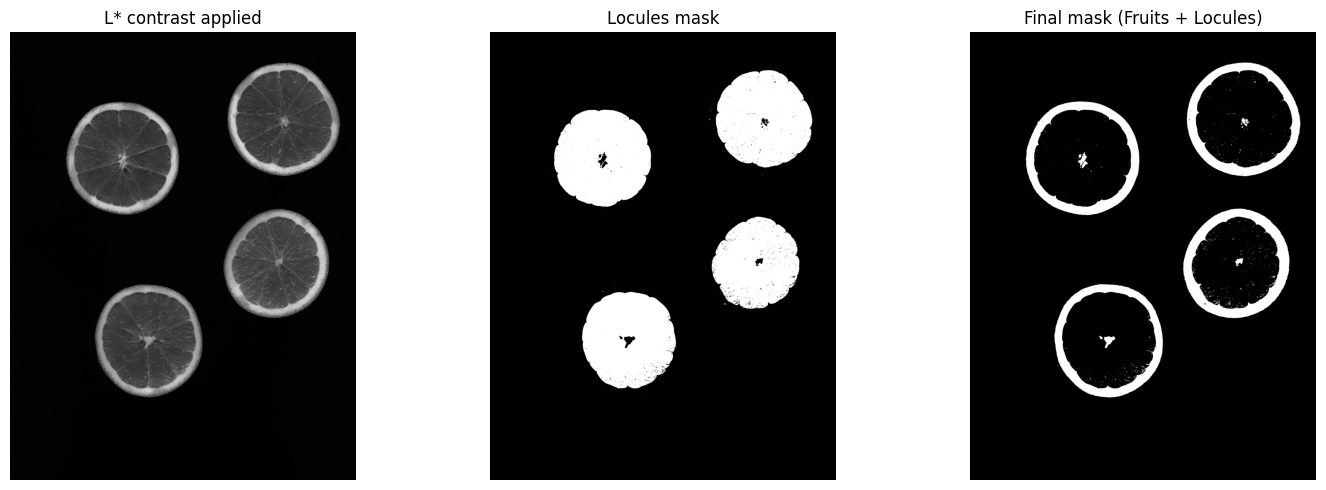

In [51]:
orange.create_mask_locules(plot = True)

Total detected objects: 2141
Detected fruits after filtering: 4


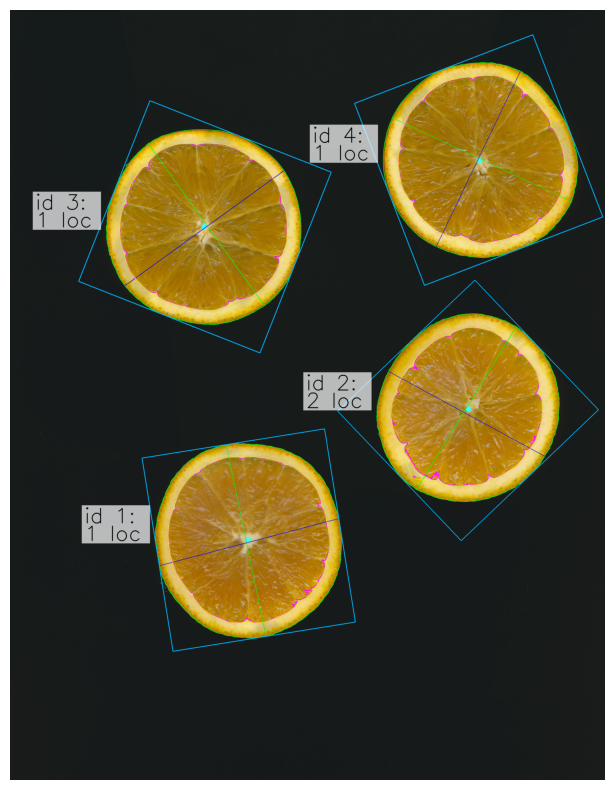

In [ ]:
orange.find_fruits()
orange.analyze_image(font_scale = 4, 
                     font_thickness = 3, 
                     label_position = 'left', 
                     centroid_fruit = 15) # Centroid dot size 